# Handling Imbalanced Data: Credit Card Fraud Detection
### Before vs After SMOTE

**Task:** Real-world classification problems (fraud, disease, churn) almost
always have a rare "positive" class. This notebook shows what happens if you
ignore that imbalance, and how to fix it with **SMOTE** (Synthetic Minority
Oversampling Technique).

Dataset: `creditcard.csv` — anonymized credit card transactions.
`Class` = 1 means fraud, `Class` = 0 means normal transaction.
Features `V1`...`V28` are PCA-transformed (already anonymized by the dataset
creators), plus `Time` and `Amount`.


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE

plt.style.use("default")


## 2. Load Data & Check Class Balance

Pehle dataset load karke dekhte hain ke `Class` column kitna imbalanced hai.

In [2]:
df = pd.read_csv("creditcard.csv")
print("Shape:", df.shape)
df.head()


Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
class_counts = df["Class"].value_counts()
print(class_counts)
print()
fraud_pct = (class_counts[1] / class_counts.sum()) * 100
print(f"Fraud cases are only {fraud_pct:.3f}% of the data")


Class
0    284315
1       492
Name: count, dtype: int64

Fraud cases are only 0.173% of the data


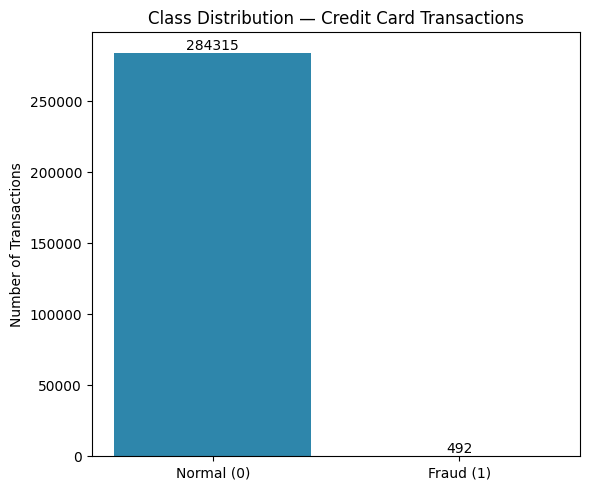

In [4]:
# Visualize class balance
fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(["Normal (0)", "Fraud (1)"], class_counts.values, color=["#2E86AB", "#E76F51"])
ax.set_ylabel("Number of Transactions")
ax.set_title("Class Distribution — Credit Card Transactions")
ax.bar_label(bars, fmt="%d")
plt.tight_layout()
plt.savefig("class_balance_before.png", dpi=150)
plt.show()


**Yaad rakhne wali baat:** Fraud sirf **0.17%** transactions mein hai.
Iska matlab agar model har transaction ko "Normal" predict kar de, tab bhi
**99.8% accuracy** milegi — lekin wo model bilkul useless hoga kyunki wo
kabhi fraud pakad hi nahi payega. Yehi is task ka core lesson hai.

## 3. Preprocessing

`Time` aur `Amount` columns already scaled nahi hain (jabke `V1`...`V28`
pehle se PCA transform ho chuke hain aur roughly similar scale par hain).
Isliye inhe `StandardScaler` se scale karenge taake Logistic Regression
theek se converge kare.

In [5]:
scaler = StandardScaler()
df[["Time", "Amount"]] = scaler.fit_transform(df[["Time", "Amount"]])

X = df.drop(columns=["Class"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Fraud cases in train:", y_train.sum(), " Fraud cases in test:", y_test.sum())


Train shape: (227845, 30)  Test shape: (56962, 30)
Fraud cases in train: 394  Fraud cases in test: 98


## 4. Baseline Model (No Imbalance Handling)

Pehle ek plain Logistic Regression train karte hain — bina kisi imbalance
technique ke — taake dekh sakein ke problem kitni real hai.

In [6]:
baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train, y_train)

baseline_preds = baseline_model.predict(X_test)

baseline_metrics = {
    "Accuracy": accuracy_score(y_test, baseline_preds),
    "Precision": precision_score(y_test, baseline_preds),
    "Recall": recall_score(y_test, baseline_preds),
    "F1-Score": f1_score(y_test, baseline_preds),
}
for k, v in baseline_metrics.items():
    print(f"{k}: {v:.4f}")


Accuracy: 0.9992
Precision: 0.8289
Recall: 0.6429
F1-Score: 0.7241


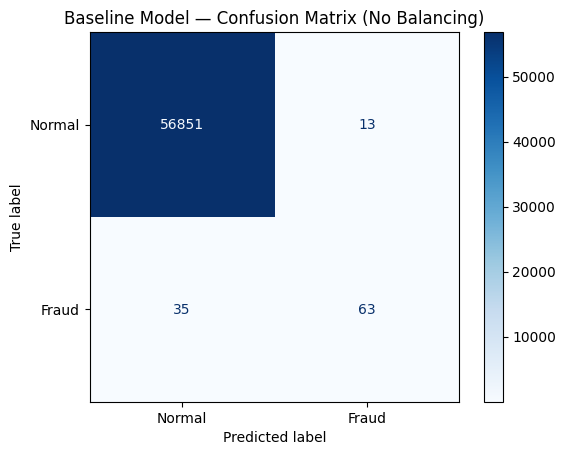

In [7]:
cm = confusion_matrix(y_test, baseline_preds)
ConfusionMatrixDisplay(cm, display_labels=["Normal", "Fraud"]).plot(cmap="Blues")
plt.title("Baseline Model — Confusion Matrix (No Balancing)")
plt.savefig("confusion_matrix_baseline.png", dpi=150)
plt.show()


Accuracy bahut high (~99.9%) dikhegi — lekin **Recall** dekho: ye batata
hai model total fraud cases mein se kitne pakad paya. Agar recall kam hai,
matlab model bohot saare fraud cases miss kar raha hai — jo ek real bank ke
liye bahut mehenga (costly) mistake hai.

## 5. Apply SMOTE (Fixing the Imbalance)

**SMOTE (Synthetic Minority Oversampling Technique)** minority class
(fraud) ke liye **naye synthetic (fake but realistic) samples** banata hai —
existing fraud examples ke beech interpolate karke — taake training data
mein dono classes barabar ho jayein.

**Important:** SMOTE hum sirf **training data** par apply karenge, test
data ko bilkul untouched rakhenge — warna model ko "fake" data par test
karke hum khud ko dhoka de rahe honge (data leakage).

In [8]:
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE: ", y_train_balanced.value_counts().to_dict())


Before SMOTE: {0: 227451, 1: 394}
After SMOTE:  {0: 227451, 1: 227451}


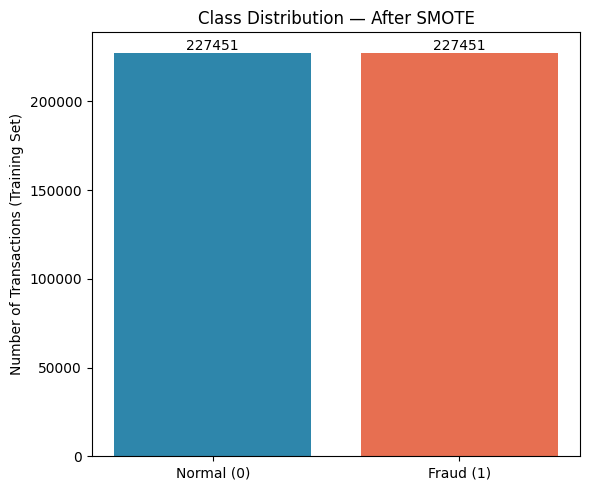

In [9]:
# Visualize the balance after SMOTE
fig, ax = plt.subplots(figsize=(6, 5))
after_counts = y_train_balanced.value_counts()
bars = ax.bar(["Normal (0)", "Fraud (1)"], after_counts.values, color=["#2E86AB", "#E76F51"])
ax.set_ylabel("Number of Transactions (Training Set)")
ax.set_title("Class Distribution — After SMOTE")
ax.bar_label(bars, fmt="%d")
plt.tight_layout()
plt.savefig("class_balance_after.png", dpi=150)
plt.show()


## 6. Retrain the Model on Balanced Data

In [10]:
balanced_model = LogisticRegression(max_iter=1000)
balanced_model.fit(X_train_balanced, y_train_balanced)

balanced_preds = balanced_model.predict(X_test)

balanced_metrics = {
    "Accuracy": accuracy_score(y_test, balanced_preds),
    "Precision": precision_score(y_test, balanced_preds),
    "Recall": recall_score(y_test, balanced_preds),
    "F1-Score": f1_score(y_test, balanced_preds),
}
for k, v in balanced_metrics.items():
    print(f"{k}: {v:.4f}")


Accuracy: 0.9743
Precision: 0.0581
Recall: 0.9184
F1-Score: 0.1094


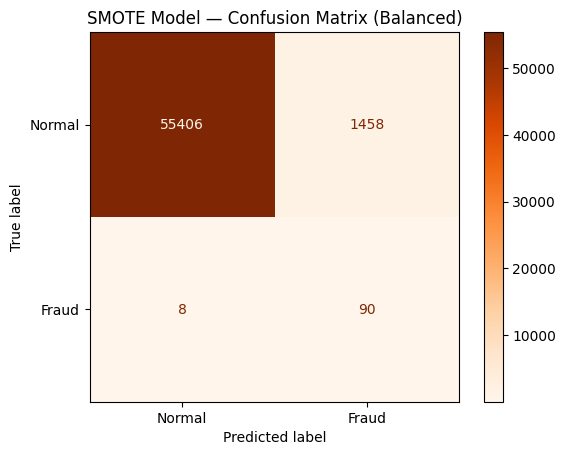

In [11]:
cm2 = confusion_matrix(y_test, balanced_preds)
ConfusionMatrixDisplay(cm2, display_labels=["Normal", "Fraud"]).plot(cmap="Oranges")
plt.title("SMOTE Model — Confusion Matrix (Balanced)")
plt.savefig("confusion_matrix_smote.png", dpi=150)
plt.show()


## 7. Before vs After Comparison Table

In [12]:
comparison = pd.DataFrame([
    {"Version": "Baseline (No Balancing)", **baseline_metrics},
    {"Version": "SMOTE (Balanced)", **balanced_metrics},
])
comparison = comparison.round(4)
comparison


,Version,Accuracy,Precision,Recall,F1-Score
0,Baseline (No Balancing),0.9992,0.8289,0.6429,0.7241
1,SMOTE (Balanced),0.9743,0.0581,0.9184,0.1094


In [13]:
print(comparison.to_markdown(index=False))


| Version                 |   Accuracy |   Precision |   Recall |   F1-Score |
|:------------------------|-----------:|------------:|---------:|-----------:|
| Baseline (No Balancing) |     0.9992 |      0.8289 |   0.6429 |     0.7241 |
| SMOTE (Balanced)        |     0.9743 |      0.0581 |   0.9184 |     0.1094 |


**What changed:** SMOTE ke baad **Recall** kaafi improve hota hai (model
zyada fraud cases pakadta hai), lekin **Precision** girta hai (model kuch
normal transactions ko bhi galti se fraud keh deta hai — false positives
zyada ho jate hain). Ye ek classic **precision-recall tradeoff** hai. Real
bank ke liye ye tradeoff acceptable hai kyunki ek missed fraud (false
negative) usually ek false alarm (false positive) se zyada mehenga hota hai.


## 8. Why Accuracy Is a Misleading Metric Here

Is dataset mein fraud sirf 0.17% transactions hai. Iska matlab agar model
**har** transaction ko "Normal" predict kar de (bina kuch bhi seekhe), tab
bhi accuracy ~99.8% aayegi — jo dekhne mein bahut acha lagta hai lekin model
ne fraud detect karne mein zero kaam kiya hai. Accuracy sirf ye batati hai
ke "total kitne sahi predict hue", lekin ye nahi batati ke minority class
(jo humein sabse zyada matter karti hai) kitni sahi pakdi gayi. Isi liye
imbalanced data ke liye **Precision, Recall, aur F1-score** zyada meaningful
hote hain — ye directly batate hain ke model fraud cases ke saath kitna
accurate hai, na ke overall dataset ke saath.


## 9. What's Left To Do Yourself (outside this notebook)

1. Is notebook ko apne GitHub repo mein push karo.
2. README.md mein Section 7 ka comparison table paste karo, aur Section 8
   ka explanation (accuracy misleading wala point) bhi add kar dena — ye
   real interviews mein bhi bahut common poocha jata hai.
